# 03. Feature Points (Gambar Standar)


<table>
  <tr>
    <td>Nama</td>
    <td>Steven Tjhia</td>
  </tr>
  <tr>
    <td>NIM</td>
    <td>13522103</td>
  </tr>
  <tr>
    <td>Fitur Unik</td>
    <td>
      Mengerjakan Harris dan SIFT
    </td>
  </tr>
</table>

## 3.1 Inisiasi

In [1]:
import os
import cv2 # OpenCV for SIFT and drawing keypoints
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, img_as_float, img_as_ubyte
from skimage.feature import corner_harris, corner_peaks, corner_fast # Harris, FAST
from skimage.color import rgb2gray # To ensure grayscale for detectors

In [2]:
output_dir = 'output'

## 3.2 Utility Functions

In [3]:
def display_comparison_features(original, marked_img, detector_name, stats_str, img_name):
    """Displays the original and marked images side-by-side."""
    fig, axes = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
    ax = axes.ravel()

    ax[0].imshow(original, cmap=plt.cm.gray if original.ndim==2 else None)
    ax[0].set_title(f'Original ({img_name})')
    ax[0].axis('off')

    # Marked image might be color (from cv2.drawKeypoints) or grayscale
    ax[1].imshow(marked_img, cmap=plt.cm.gray if marked_img.ndim==2 else None)
    ax[1].set_title(f'{detector_name} Features\n{stats_str}')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

## 3.3 Experiments

### 3.3.1 Load Images

In [4]:
print("--- Loading Images ---")
try:
    camera = img_as_float(data.camera())
    coins = img_as_float(data.coins())
    checkerboard_img = img_as_float(data.checkerboard())

    images = {
        'camera': camera,
        'coins': coins,
        'checkerboard': checkerboard_img
    }
    print("Images loaded successfully.")

except Exception as e:
    print(f"Error loading images: {e}")
    images = {}
    
print("\n--- Saving Original Images ---")
for name, img in images.items():
    raw_output_filename = os.path.join("raw", f'raw_{name}.png')
    try:
        io.imsave(raw_output_filename, img_as_ubyte(img))
        print(f"Saved original image to: {raw_output_filename}")
    except Exception as e:
        print(f"Error saving original image {raw_output_filename}: {e}")

--- Loading Images ---
Images loaded successfully.

--- Saving Original Images ---
Saved original image to: raw\raw_camera.png
Saved original image to: raw\raw_coins.png
Saved original image to: raw\raw_checkerboard.png


### 3.3.2 Harris

Params

<table>
    <tr>
        <td>Min. Dist.</td>
        <td>5</td>
    </tr>
</table>


Processing camera with Harris...
Params: k=0.05, min_dist=5
Features found: 133
Response: Min=0.0523, Max=5.2088, Mean=0.5912, Std=0.7927
Saved Harris marked image to: output\harris_output_camera.png


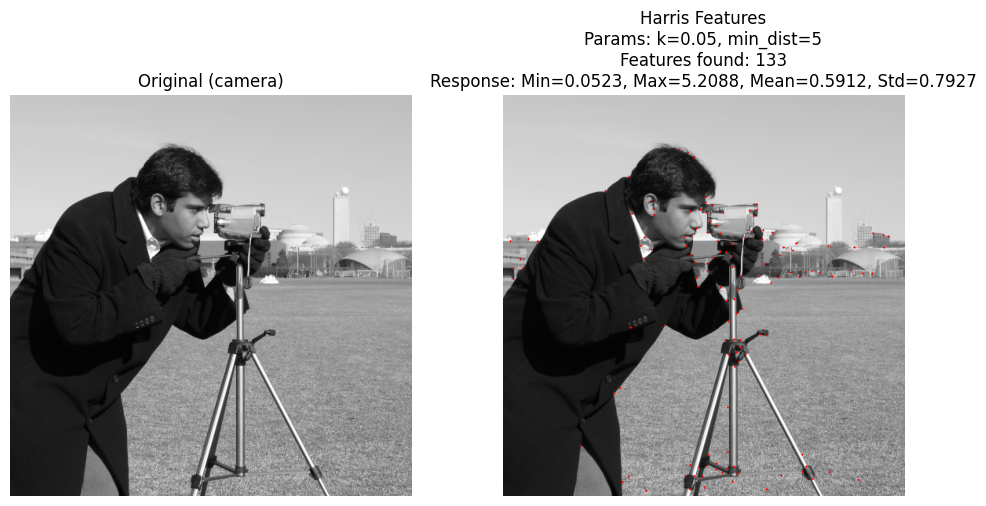


Processing coins with Harris...
Params: k=0.05, min_dist=5
Features found: 149
Response: Min=0.0270, Max=2.6879, Mean=0.1969, Std=0.3140
Saved Harris marked image to: output\harris_output_coins.png


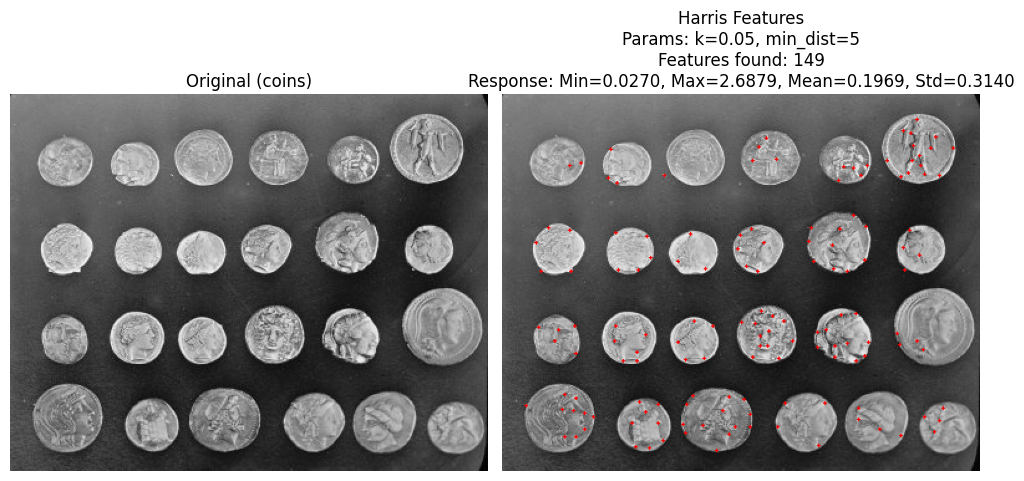


Processing checkerboard with Harris...
Params: k=0.05, min_dist=5
Features found: 49
Response: Min=6.4412, Max=6.4412, Mean=6.4412, Std=0.0000
Saved Harris marked image to: output\harris_output_checkerboard.png


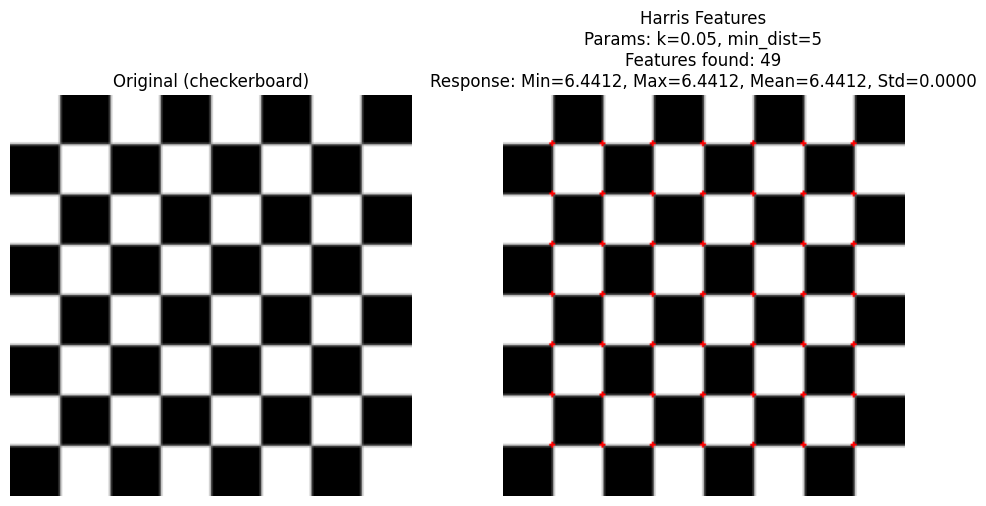

In [6]:
harris_k = 0.05
harris_min_dist = 5 # Minimum distance between detected peaks

for name, img_gray in images.items():
    print(f"\nProcessing {name} with Harris...")

    # Calculate Harris response image
    harris_response = corner_harris(img_gray, k=harris_k)

    # Find peak coordinates in response image
    coordinates = corner_peaks(harris_response, min_distance=harris_min_dist, threshold_rel=0.01)

    num_features = len(coordinates)
    stats_str = f'Params: k={harris_k}, min_dist={harris_min_dist}\nFeatures found: {num_features}'

    # Calculate response stats if features found
    if num_features > 0:
        responses_harris = harris_response[coordinates[:, 0], coordinates[:, 1]]
        resp_min = np.min(responses_harris)
        resp_max = np.max(responses_harris)
        resp_mean = np.mean(responses_harris)
        resp_std = np.std(responses_harris)
        stats_str += f'\nResponse: Min={resp_min:.4f}, Max={resp_max:.4f}, Mean={resp_mean:.4f}, Std={resp_std:.4f}'
    else:
        stats_str += '\nResponse: N/A (no features found)'

    print(stats_str)

    # Create image with markers directly on array
    img_display_orig = images[name]
    # Convert to color uint8 for drawing red circles
    if img_display_orig.ndim == 2:
        img_display_marked = cv2.cvtColor(img_as_ubyte(img_display_orig), cv2.COLOR_GRAY2BGR)
    else:
        img_display_marked = img_as_ubyte(img_display_orig.copy()) # Make a copy if already color

    # Draw circles using OpenCV
    for coord in coordinates:
        row, col = coord
        center = (int(col), int(row))
        cv2.circle(img_display_marked, center, radius=1, color=(0, 0, 255), thickness=-1) # Red circle, filled

    # Save the marked image array
    output_filename_array = os.path.join(output_dir, f'harris_output_{name}.png')
    try:
        io.imsave(output_filename_array, cv2.cvtColor(img_display_marked, cv2.COLOR_BGR2RGB))
        print(f"Saved Harris marked image to: {output_filename_array}")
    except Exception as e:
        print(f"Error saving Harris marked image {output_filename_array}: {e}")

    # Display comparison
    display_comparison_features(img_as_ubyte(images[name]), cv2.cvtColor(img_display_marked, cv2.COLOR_BGR2RGB), 'Harris', stats_str, name)

Params

<table>
    <tr>
        <td>Min. Dist.</td>
        <td>15</td>
    </tr>
</table>


Processing camera with Harris...
Params: k=0.05, min_dist=15
Features found: 48
Response: Min=0.0523, Max=5.2088, Mean=0.9333, Std=1.0804
Saved Harris marked image to: output\harris_output_camera_min_dist_15.png


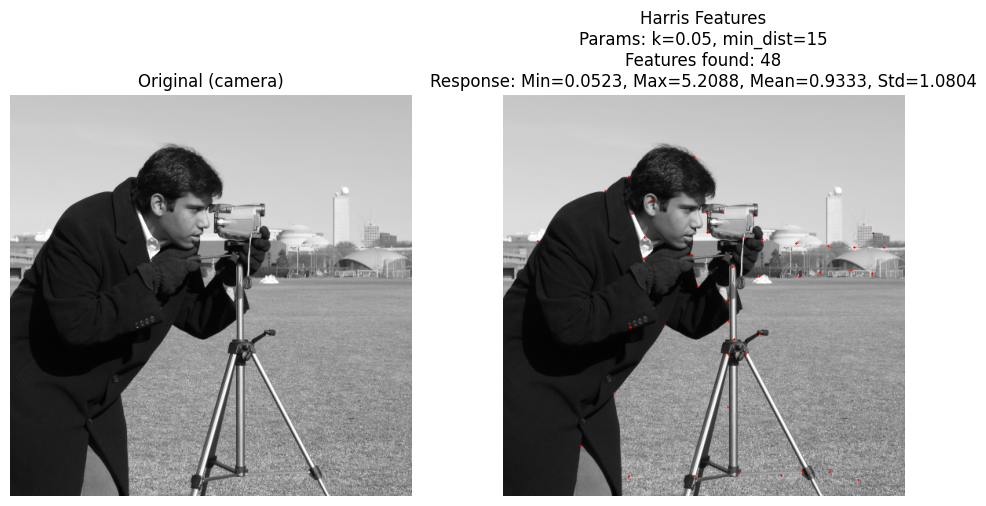


Processing coins with Harris...
Params: k=0.05, min_dist=15
Features found: 59
Response: Min=0.0281, Max=2.6879, Mean=0.3241, Std=0.4428
Saved Harris marked image to: output\harris_output_coins_min_dist_15.png


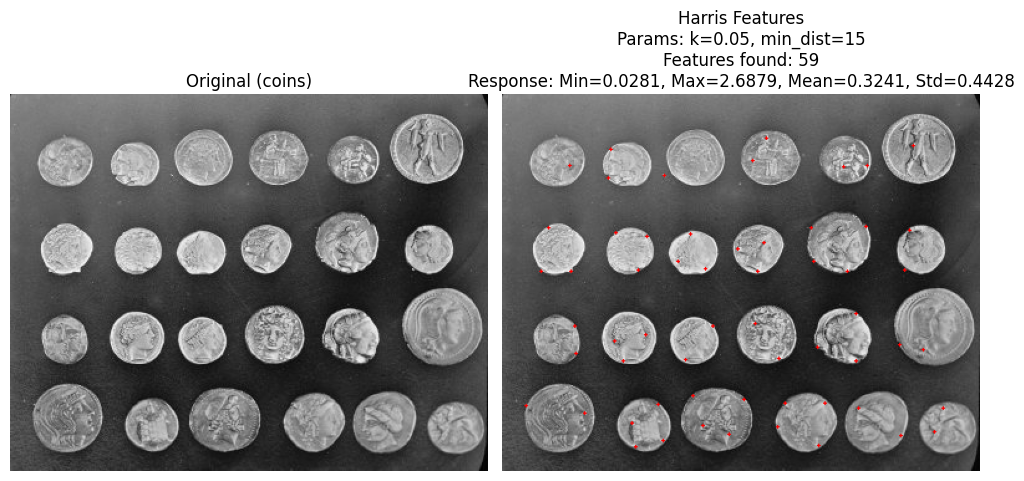


Processing checkerboard with Harris...
Params: k=0.05, min_dist=15
Features found: 49
Response: Min=6.4412, Max=6.4412, Mean=6.4412, Std=0.0000
Saved Harris marked image to: output\harris_output_checkerboard_min_dist_15.png


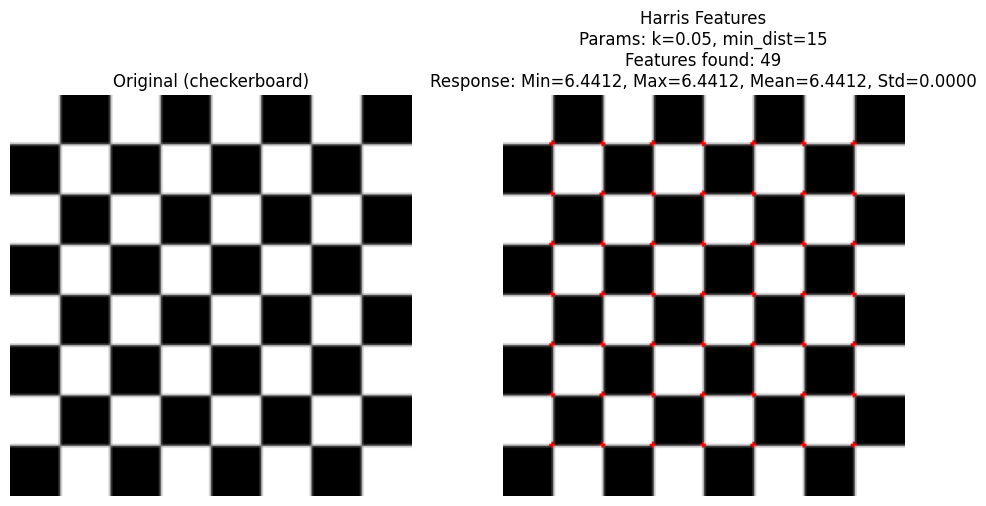

In [6]:
harris_k = 0.05
harris_min_dist = 15 # Minimum distance between detected peaks

for name, img_gray in images.items():
    print(f"\nProcessing {name} with Harris...")

    # Calculate Harris response image
    harris_response = corner_harris(img_gray, k=harris_k)

    # Find peak coordinates in response image
    coordinates = corner_peaks(harris_response, min_distance=harris_min_dist, threshold_rel=0.01)

    num_features = len(coordinates)
    stats_str = f'Params: k={harris_k}, min_dist={harris_min_dist}\nFeatures found: {num_features}'

    # Calculate response stats if features found
    if num_features > 0:
        responses_harris = harris_response[coordinates[:, 0], coordinates[:, 1]]
        resp_min = np.min(responses_harris)
        resp_max = np.max(responses_harris)
        resp_mean = np.mean(responses_harris)
        resp_std = np.std(responses_harris)
        stats_str += f'\nResponse: Min={resp_min:.4f}, Max={resp_max:.4f}, Mean={resp_mean:.4f}, Std={resp_std:.4f}'
    else:
        stats_str += '\nResponse: N/A (no features found)'

    print(stats_str)

    # Create image with markers directly on array
    img_display_orig = images[name]
    # Convert to color uint8 for drawing red circles
    if img_display_orig.ndim == 2:
        img_display_marked = cv2.cvtColor(img_as_ubyte(img_display_orig), cv2.COLOR_GRAY2BGR)
    else:
        img_display_marked = img_as_ubyte(img_display_orig.copy()) # Make a copy if already color

    # Draw circles using OpenCV
    for coord in coordinates:
        row, col = coord
        center = (int(col), int(row))
        cv2.circle(img_display_marked, center, radius=1, color=(0, 0, 255), thickness=-1) # Red circle, filled

    # Save the marked image array
    output_filename_array = os.path.join(output_dir, f'harris_output_{name}_min_dist_15.png')
    try:
        io.imsave(output_filename_array, cv2.cvtColor(img_display_marked, cv2.COLOR_BGR2RGB))
        print(f"Saved Harris marked image to: {output_filename_array}")
    except Exception as e:
        print(f"Error saving Harris marked image {output_filename_array}: {e}")

    # Display comparison
    display_comparison_features(img_as_ubyte(images[name]), cv2.cvtColor(img_display_marked, cv2.COLOR_BGR2RGB), 'Harris', stats_str, name)

### 3.3.3 SIFT (Scale-Invariant Feature Transform)


Processing camera with SIFT...
Features found: 791
Response: Min=0.0134, Max=0.1016, Mean=0.0318, Std=0.0166
Saved SIFT marked image to: output\sift_output_camera.png


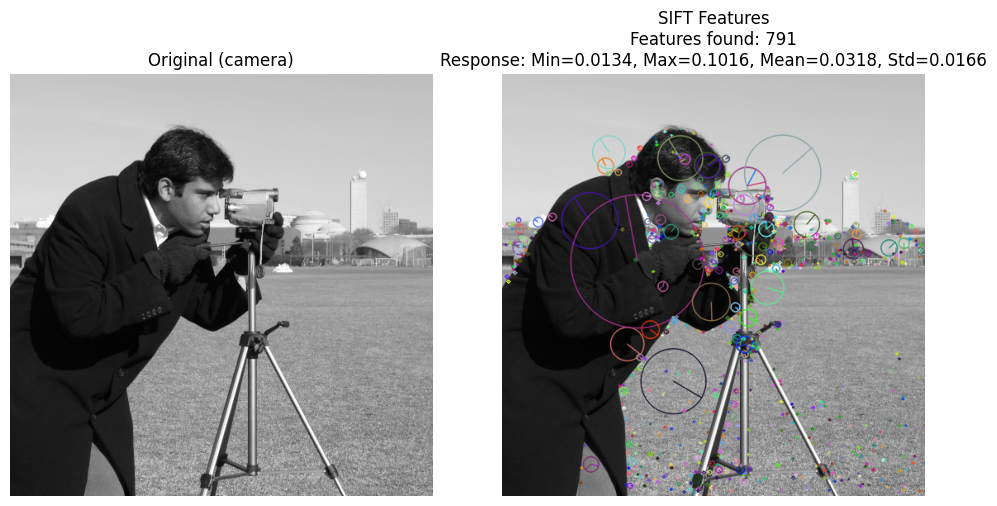


Processing coins with SIFT...
Features found: 655
Response: Min=0.0134, Max=0.0834, Mean=0.0297, Std=0.0130
Saved SIFT marked image to: output\sift_output_coins.png


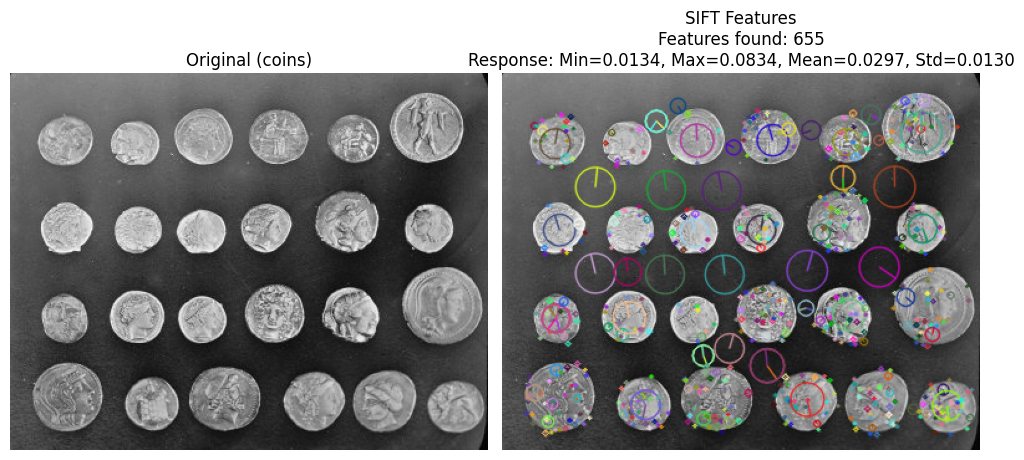


Processing checkerboard with SIFT...
Features found: 134
Response: Min=0.0822, Max=0.1293, Mean=0.1285, Std=0.0057
Saved SIFT marked image to: output\sift_output_checkerboard.png


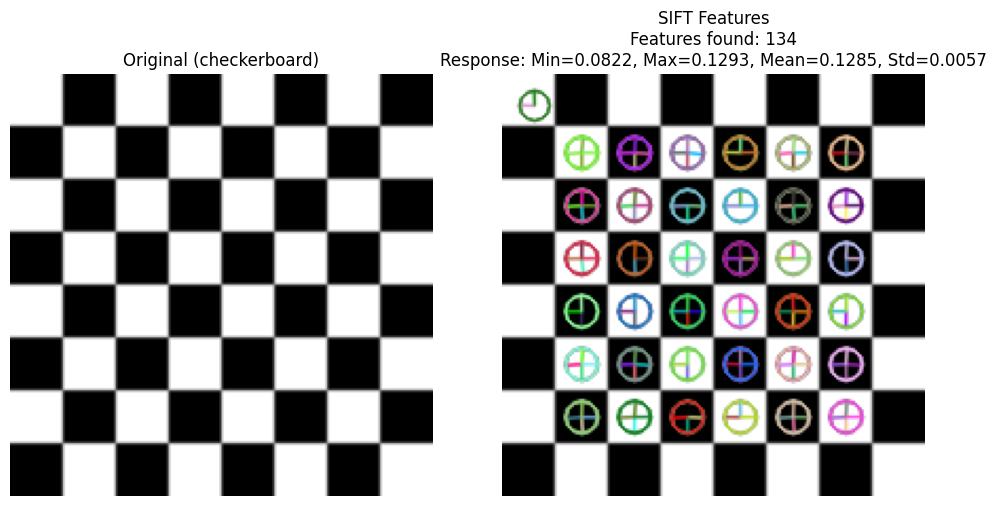

In [7]:
sift = cv2.SIFT_create()
for name, img_gray in images.items():
    print(f"\nProcessing {name} with SIFT...")

    img_uint8 = img_as_ubyte(img_gray)
    keypoints = sift.detect(img_uint8, None)
    num_features = len(keypoints)
    stats_str = f'Features found: {num_features}'

    # Calculate response stats if features found
    if num_features > 0:
        responses_sift = np.array([kp.response for kp in keypoints])
        resp_min = np.min(responses_sift)
        resp_max = np.max(responses_sift)
        resp_mean = np.mean(responses_sift)
        resp_std = np.std(responses_sift)
        stats_str += f'\nResponse: Min={resp_min:.4f}, Max={resp_max:.4f}, Mean={resp_mean:.4f}, Std={resp_std:.4f}'
    else:
        stats_str += '\nResponse: N/A (no features found)'

    print(stats_str)

    img_original_uint8_color = cv2.cvtColor(img_as_ubyte(images[name]), cv2.COLOR_GRAY2BGR) if images[name].ndim == 2 else img_as_ubyte(images[name])
    sift_marked_img = cv2.drawKeypoints(img_original_uint8_color, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    output_filename_cv = os.path.join(output_dir, f'sift_output_{name}.png')
    try:
        io.imsave(output_filename_cv, cv2.cvtColor(sift_marked_img, cv2.COLOR_BGR2RGB))
        print(f"Saved SIFT marked image to: {output_filename_cv}")
    except Exception as e:
        print(f"Error saving SIFT marked image {output_filename_cv}: {e}")

    display_comparison_features(img_as_ubyte(images[name]), cv2.cvtColor(sift_marked_img, cv2.COLOR_BGR2RGB), 'SIFT', stats_str, name)